# PACE Rapid Response Workflow

# EDIT COPY FROM HURRICANE HUMBERTO - Ernesto (2024)

This Jupyter notebook serves as the first example to rapidly access, download, review, and develop science data products is support of the NASA PACE Mission. In this notebook we investigate the impacts of Hurricane Erin that formed in mid-August of 2025. In particular we attempt to analyze different ecologically relevant biogeochemical parameters before and after the extreme strom off the southeastern shore of the United States.

Scientific Premise: "Remotely sensed ocean color shows increased concentrations of surface chlorophyll within the cool wakes of the hurricanes, apparently in response to the injection of nutrients and/or biogenic pigments into the oligotrophic surface waters. This increase in post-storm surface chlorophyll concentration usually lasted 2–3 weeks before it returned to its nominal pre-hurricane levels" Citation: https://doi.org/10.1029/2003JC001938

Matthew Kehrli & Graham Trolley

NASA Ocean Ecology Laboratory

November 2025

### Case Study Information

Hurricane Ernesto (2024), look at biogeochemical and optical parameters before and after hurricane off US East Coast shelf. Hurricanes tend to mix nutrients leading to an increase productivity.

Timeline (using worldview):
- Define the region of interest as the area off east coast the gulf stream bounded by the box formed by 20N 75W, 60N 50W - narrow area later
- Hurricane off florida/gulf stream in PACE imagery on August 16-19th
- Aug 20, hurricane passed and clear imagery
- Before August 16th, the hurrican has yet to arrive to the region of interest

### Basic Steps
- Use worldview to identify an event and region of interest to examine (basic before/after)
- Define lat lon bounds, and time range for pre- and post-event averages
- Earthdata search using parameters. Open the first one by itself to establish gridding params
- Use dask to open all the pre-event granules
- Use dask to open all the post-event granules
- Make initial analysis plots
- Return pre and post dataframes to user, to allow them to make more custom plots?


https://www.nhc.noaa.gov/data/tcr/index.php?season=2024&basin=atl

### Imports

In [1]:
# Standard Library Imports
import os
import re
import glob
import warnings
from collections import defaultdict
from io import BytesIO

# Third-Party Library Imports
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
from matplotlib.colors import LogNorm, LinearSegmentedColormap, ListedColormap
import cmocean
import colormaps as cmaps
import cartopy.crs as ccrs
from dask.distributed import Client
from PIL import Image, ImageEnhance
from IPython.display import Image as gifImage
import imageio
import earthaccess
import rioxarray

### User Defined Functions

In [2]:
# Define Functions, don't modify
def grid_match(path, dst_crs, dst_shape, dst_transform, variable):
    """
    Reproject a Level-2 granule to match a Level-3M-ish granule.
    """
    dt = xr.open_datatree(path,decode_timedelta=True)
    da = dt["geophysical_data"][variable]
    da = da.rio.set_spatial_dims("pixels_per_line", "number_of_lines")
    da = da.rio.write_crs("epsg:4326")
    da = da.rio.reproject(
        dst_crs,
        shape=dst_shape,
        transform=dst_transform,
        src_geoloc_array=(
            dt["navigation_data"]["longitude"],
            dt["navigation_data"]["latitude"],
        ),
    )
    da = da.rename({"x":"longitude", "y":"latitude"})
    return da

def grid_match_SREF(path, dst_crs, dst_shape, dst_transform, variable):
    """Reproject a Level-2 granule to match a Level-3M-ish granule."""
    dt = xr.open_datatree(path,decode_timedelta=True)
    da = dt["geophysical_data"][variable]
    da = da.transpose('wavelength_3d', 'number_of_lines', 'pixels_per_line')
    da = da.rio.set_spatial_dims("pixels_per_line", "number_of_lines")
    da = da.rio.write_crs("epsg:4326")
    da = da.rio.reproject(
        dst_crs,
        shape=dst_shape,
        transform=dst_transform,
        src_geoloc_array=(
            dt["navigation_data"]["longitude"],
            dt["navigation_data"]["latitude"],
        ),
    )
    da = da.rename({"x":"longitude", "y":"latitude"})
    return da


def time_from_attr(ds):
    """
    Set the start time attribute as a dataset variable.
 
    Parameters
    ----------
    ds: a dataset corresponding to a Level-2 granule

    """
    datetime = ds.attrs["time_coverage_start"].replace("Z", "")
    ds["time"] = ((), np.datetime64(datetime, "ns"))
    ds = ds.set_coords("time")
    return ds

def time_from_attr_L4MOANNA(ds):
    # Extract the date (YYYYMMDD) from the 'id' attribute
    id_str = ds.attrs["id"]
    match = re.search(r"\.(\d{8})\.", id_str)
    if match:
        date_str = match.group(1)
        # Convert to YYYY-MM-DD format
        date_fmt = f"{date_str[:4]}-{date_str[4:6]}-{date_str[6:]}"
        datetime = f"{date_fmt}T00:00:00"
        ds["time"] = ((), np.datetime64(datetime))
        ds = ds.set_coords("time")
    else:
        raise ValueError("Date not found in 'id' attribute.")
    return ds


def time_from_attr_sst(ds):
    ds = ds.set_coords("time")
    return ds



def load_first(path, var):
    """
    Load the first file returned in earthdata search, then manipulate to L3M-like, and 
    store the crs, shape, and transform to make opening all the search result granules fast
    
    """
    datatree = xr.open_datatree(path,decode_timedelta=True)
    dataset = xr.merge(datatree.to_dict().values())
    dataset = dataset.set_coords(("longitude", "latitude"))

    var_data = dataset[var]# use code from dask_gridding notebook to transform L2 granule to L3M-like grid
    var_data = var_data.rio.set_spatial_dims("pixels_per_line", "number_of_lines")
    var_data = var_data.rio.write_crs("epsg:4326")
    var_L3M = var_data.rio.reproject(
        dst_crs="epsg:4326",
        src_geoloc_array=(
            var_data.coords["longitude"],
            var_data.coords["latitude"],
        ),
    )
    var_L3M = var_L3M.rename({"x":"longitude", "y":"latitude"})

    #var_L3M_aoi = var_L3M.sel({"longitude": slice(bbox[0], bbox[2]),"latitude": slice(bbox[3], bbox[1])})

    # Extend to bounding box
    var_L3M_aoi = var_L3M.rio.pad_box(
        minx=bbox[0],
        miny=bbox[1],
        maxx=bbox[2],
        maxy=bbox[3],
        constant_values=np.nan
    )

    crs = var_L3M_aoi.rio.crs# set mapping parameters from newly transformed file, to use when opening the rest with dask
    shape = var_L3M_aoi.rio.shape
    transform = var_L3M_aoi.rio.transform()

    return crs, shape, transform

def load_first_SREF(path, var):
    """
    Load the first file returned in earthdata search, then manipulate to L3M-like, and
    store the crs, shape, and transform to make opening all the search result granules fast

    """
    datatree = xr.open_datatree(path,decode_timedelta=True)
    dataset = xr.merge(datatree.to_dict().values())
    dataset = dataset.isel(pixels_per_line=slice(13,None))
    dataset = dataset.set_coords(("longitude", "latitude"))

    var_data = dataset[var]# use code from dask_gridding notebook to transform L2 granule to L3M-like grid
    var_data = var_data.transpose('wavelength_3d', 'number_of_lines', 'pixels_per_line')
    var_data = var_data.rio.set_spatial_dims("pixels_per_line", "number_of_lines")

    var_data = var_data.rio.write_crs("epsg:4326")
    var_L3M = var_data.rio.reproject(
        dst_crs="epsg:4326",
        src_geoloc_array=(
            var_data.coords["longitude"],
            var_data.coords["latitude"],
        ),
    )
    var_L3M = var_L3M.rename({"x":"longitude", "y":"latitude"})

    # Extend to bounding box
    var_L3M_aoi = var_L3M.rio.pad_box(
        minx=bbox[0],
        miny=bbox[1],
        maxx=bbox[2],
        maxy=bbox[3],
        constant_values=np.nan
    )
    crs = var_L3M_aoi.rio.crs# set mapping parameters from newly transformed file, to use when opening the rest with dask
    shape = var_L3M_aoi.rio.shape 
    wl = var_L3M_aoi['wavelength_3d']
    transform = var_L3M_aoi.rio.transform()

    return crs, shape, transform, wl


def coregister_granules(paths, crs, shape, transform, var_name):
    """
    Use geographic parameters returned from load_first function to open all the granules for a given "paths"
    Variable returned by earthdata search. returns an xarray dataset, where the time dimension differentiates
    data from each different granule

    """

    warnings.filterwarnings("ignore") # suppress warnings for cleaner output
    client = Client()

    futures = client.map(grid_match,paths,dst_crs=crs,dst_shape=shape,dst_transform=transform, variable = var_name)
    kwargs = {"combine": "nested", "concat_dim": "time"}
    attrs = xr.open_mfdataset(paths, preprocess=time_from_attr, **kwargs)
    data = xr.combine_nested(client.gather(futures), concat_dim="time")# open  all pre files. they are stored in same xarray dataset at different "time" coordinates 
    data["time"] = attrs["time"]
    client.close()
    print('loaded pre event files')

    return data

def coregister_granules_SREF(paths, crs, shape, transform, var_name):
    """
    Use geographic parameters returned from load_first function to open all the granules for a given "paths" 
    Variable returned by earthdata search. returns an xarray dataset, where the time dimension differentiates
    data from each different granule

    """

    warnings.filterwarnings("ignore") # suppress warnings for cleaner output
    client = Client()

    futures = client.map(grid_match_SREF,paths,dst_crs=crs,dst_shape=shape,dst_transform=transform, variable = var_name)
    kwargs = {"combine": "nested", "concat_dim": "time"}
    attrs = xr.open_mfdataset(paths, preprocess=time_from_attr, **kwargs)
    data = xr.combine_nested(client.gather(futures), concat_dim="time")# open all pre files. they are stored in same xarray dataset at different "time" coordinates 
    data["time"] = attrs["time"]
    client.close()
    print('loaded pre event files')

    return data

def enhance(rgb, scale = 0.01, vmin = 0.01, vmax = 1.04, gamma=0.95, contrast=1.2, brightness=1.1, sharpness=2, saturation=1.1):
    """The SeaDAS recipe for RGB images from Ocean Color missions.

    Args:
        rgb: a data array with three dimensions, having 3 or 4 bands in the third dimension
        scale: scale value for the log transform
        vmin: minimum pixel value for the image
        vmax: maximum pixel value for the image
        gamma: exponential factor for gamma correction
        contrast: amount of pixel value differentiation 
        brightness: pixel values (intensity)
        sharpness: amount of detail
        saturation: color intensity

    Returns:
       a transformed data array better for RGB display
    """
    rgb = rgb.where(rgb > 0)
    rgb = np.log(rgb / scale) / np.log(1 / scale)
    rgb = rgb.where(rgb >= vmin, vmin)
    rgb = rgb.where(rgb <= vmax, vmax)    
    rgb_min = rgb.min(("latitude", "longitude"))
    rgb_max = rgb.max(("latitude", "longitude"))
    rgb = (rgb - rgb_min) / (rgb_max - rgb_min)
    rgb = rgb * gamma
    img = rgb * 255
    img = img.where(img.notnull(), 0).astype("uint8")
    img = Image.fromarray(img.data)
    enhancer = ImageEnhance.Contrast(img)
    img = enhancer.enhance(contrast)
    enhancer = ImageEnhance.Brightness(img)
    img = enhancer.enhance(brightness)
    enhancer = ImageEnhance.Sharpness(img)
    img = enhancer.enhance(sharpness)
    enhancer = ImageEnhance.Color(img)
    img = enhancer.enhance(saturation)
    rgb[:] = np.array(img) / 255
    return rgb

# functions to make wavelength-accurate avw colormap, no need to change
def wavelength_to_rgb(wavelength):
    """
    Convert a wavelength in the range 380-750 nm to an RGB color.
    Source: http://www.had2know.com/technology/rgb-color-wavelength-conversion.html

    """
    gamma = 0.8
    intensity_max = 255

    if (wavelength >= 380) and (wavelength < 440):
        R = -(wavelength - 440) / (440 - 380)
        G = 0.0
        B = 1.0
    elif (wavelength >= 440) and (wavelength < 490):
        R = 0.0
        G = (wavelength - 440) / (490 - 440)
        B = 1.0
    elif (wavelength >= 490) and (wavelength < 510):
        R = 0.0
        G = 1.0
        B = -(wavelength - 510) / (510 - 490)
    elif (wavelength >= 510) and (wavelength < 580):
        R = (wavelength - 510) / (580 - 510)
        G = 1.0
        B = 0.0
    elif (wavelength >= 580) and (wavelength < 645):
        R = 1.0
        G = -(wavelength - 645) / (645 - 580)
        B = 0.0
    elif (wavelength >= 645) and (wavelength <= 750):
        R = 1.0
        G = 0.0
        B = 0.0
    else:
        R = G = B = 0.0

    # Adjust intensity and apply gamma correction
    R = round(intensity_max * (R**gamma))/255
    G = round(intensity_max * (G**gamma))/255
    B = round(intensity_max * (B**gamma))/255

    return (R, G, B)


def generate_colormap(min_wavelength=380, max_wavelength=750, num_colors=256):
    """
    Generates a colormap for wavelengths between `min_wavelength` and `max_wavelength`.

    """
    # Ensure the wavelengths are within the visible range
    min_wavelength = max(min_wavelength, 380)
    max_wavelength = min(max_wavelength, 750)

    # Generate a list of wavelengths between min and max
    wavelengths = np.linspace(min_wavelength, max_wavelength, num_colors)
    #print(wavelengths)
    # Convert wavelengths to RGB colors
    colors = [wavelength_to_rgb(w) for w in wavelengths]
    #print(colors)
    # Create a LinearSegmentedColormap using the RGB colors
    cmap = LinearSegmentedColormap.from_list("wavelength_cmap", colors, num_colors)
    return cmap

def get_hurricane_path(storm_id):
    # Read all tables from a URL
    tables = pd.read_html('https://rammb-data.cira.colostate.edu/tc_realtime/storm.asp?storm_identifier=' + storm_id)

    track = tables[1]

    # Set the first row as column headers and remove it from data
    track.columns = track.iloc[0]  # Set first row as column names
    track = track.drop(track.index[0])  # Remove the first row from data
    track.reset_index(drop=True, inplace=True)  # Reset index to start from 0

    track['Synoptic Time'] = pd.to_datetime(track['Synoptic Time'])
    track = track.rename(columns={'Synoptic Time': 'datetime'})
    track = track.sort_values('datetime')
    track['Latitude'] = pd.to_numeric(track['Latitude'])
    track['Longitude'] = pd.to_numeric(track['Longitude'])
    track['Intensity'] = pd.to_numeric(track['Intensity'])

    return track

### Download initial event surface reflectance imagery

We define the event as an approximently three week period before/after Hurricane Erin entered 29N, 72.5W. In this scenario this step relies on 63 individual satellite data granules, which may strain CPU resourses.

In [3]:
# User definitions:
tspan = ("2024-08-09", "2024-08-20")    # define your pre-event and post-event timespans

min_lon = -75       # Set lat/lon extent for area of interest
min_lat = 20
max_lon = -50
max_lat = 60

# OCI suite and variable of interest within a particular suite
short_name="PACE_OCI_L2_SFREFL"#_NRT"
short_name_bgc="PACE_OCI_L2_BGC"#_NRT"
var_name = "rhos" # variable of interest
var_name_2 = "chlor_a" # variable of interest

local_data_path = "local_data/Hurricane_Ernesto/"

in_the_cloud = False # set to true if running in cloud (e.g. Cryocloud), false if running locally. For speed, granules will be downloaded to a local_data directory when set to false

In [5]:
# Perform the earthdata search:
bbox = (min_lon, min_lat, max_lon, max_lat)

results = earthaccess.search_data(
    short_name=short_name,
    temporal=tspan,
    bounding_box=bbox,
    version="3.1"
)

BGC_results = earthaccess.search_data(
    short_name=short_name_bgc,
    temporal=tspan,
    bounding_box=bbox,
    version="3.1"
)

if len(results) == 0 or len(BGC_results) == 0:
    short_name_alt = short_name+"_NRT"
    short_name_bgc_alt = short_name_bgc+"_NRT"

    print(f"No results found for {short_name} or {short_name_bgc}, trying {short_name_alt} and {short_name_bgc_alt} instead.")

    results = earthaccess.search_data(
        short_name=short_name_alt,
        temporal=tspan,
        bounding_box=bbox,
        version="3.1"
    )
    BGC_results = earthaccess.search_data(
        short_name=short_name_bgc_alt,
        temporal=tspan,
        bounding_box=bbox,
        version="3.1"
    )

# Print the number of granules found
print(" Number of srefl granules: "+str(len(results)))
print(" Number of BGC pre-event granules: "+str(len(BGC_results)))

# in running this script in the cloud, earthaccess.open is fast, but when running locally it takes a long time (10+ min), and locally downloading the data is faster.
# so, get the data with different approaches, depening on whether you are in the cloud or not, defined above
if in_the_cloud == True:
    paths = earthaccess.open(results)
    paths_BGC = earthaccess.open(BGC_results)
else:
    paths = earthaccess.download(results, local_path="local_data/Hurricane_Ernesto/")
    paths_BGC = earthaccess.download(BGC_results, local_path="local_data/Hurricane_Ernesto/")

print('Files Downloaded')

 Number of srefl granules: 106
 Number of BGC pre-event granules: 106


QUEUEING TASKS | : 100%|██████████| 106/106 [00:00<00:00, 7398.10it/s]
PROCESSING TASKS | : 100%|██████████| 106/106 [00:00<00:00, 205546.10it/s]
COLLECTING RESULTS | : 100%|██████████| 106/106 [00:00<00:00, 378058.01it/s]
QUEUEING TASKS | : 100%|██████████| 106/106 [00:00<00:00, 4184.51it/s]
PROCESSING TASKS | : 100%|██████████| 106/106 [00:00<00:00, 189674.16it/s]
COLLECTING RESULTS | : 100%|██████████| 106/106 [00:00<00:00, 373610.27it/s]

Files Downloaded


In [6]:
# Extract the geospatial characteristics from the first file in paths 
crs, shape, transform, wl = load_first_SREF(paths[0], var_name)
crs_BGC, shape_BGC, transform_BGC = load_first(paths_BGC[0], var_name_2)

In [7]:
# Set up method to group paths by date which will be used to make daily composites

# Regex pattern to extract the date in the format YYYYMMDD
date_pattern = re.compile(r"\.(\d{8})T")

# Dictionary to store paths grouped by date
paths_by_date = defaultdict(list)
paths_by_date_BGC = defaultdict(list)

# Iterate over paths and group by date
for path in paths:
    # Extract the date from the filename
    filename = os.path.basename(path)
    match = date_pattern.search(filename)
    if match:
        date = match.group(1)  # Extracted date (e.g., "20250817")
        paths_by_date[date].append(path)

# Print grouped paths
for date, paths in paths_by_date.items():
    print(f"Date: {date}, Number of surface reflectance files: {len(paths)}")
    print(paths)

# Iterate over paths_BGC and group by date
for path in paths_BGC:
    # Extract the date from the filename
    filename = os.path.basename(path)
    match = date_pattern.search(filename)
    if match:
        date = match.group(1)  # Extracted date (e.g., "20250817")
        paths_by_date_BGC[date].append(path)
        
# Print grouped paths for BGC
for date, paths in paths_by_date_BGC.items():
    print(f"Date: {date}, Number of BGC files: {len(paths)}")
    print(paths)

Date: 20240809, Number of surface reflectance files: 8
[PosixPath('local_data/Hurricane_Ernesto/PACE_OCI.20240809T141235.L2.SFREFL.V3_1.nc'), PosixPath('local_data/Hurricane_Ernesto/PACE_OCI.20240809T141735.L2.SFREFL.V3_1.nc'), PosixPath('local_data/Hurricane_Ernesto/PACE_OCI.20240809T154553.L2.SFREFL.V3_1.nc'), PosixPath('local_data/Hurricane_Ernesto/PACE_OCI.20240809T155053.L2.SFREFL.V3_1.nc'), PosixPath('local_data/Hurricane_Ernesto/PACE_OCI.20240809T155553.L2.SFREFL.V3_1.nc'), PosixPath('local_data/Hurricane_Ernesto/PACE_OCI.20240809T172411.L2.SFREFL.V3_1.nc'), PosixPath('local_data/Hurricane_Ernesto/PACE_OCI.20240809T172911.L2.SFREFL.V3_1.nc'), PosixPath('local_data/Hurricane_Ernesto/PACE_OCI.20240809T173411.L2.SFREFL.V3_1.nc')]
Date: 20240810, Number of surface reflectance files: 10
[PosixPath('local_data/Hurricane_Ernesto/PACE_OCI.20240810T144707.L2.SFREFL.V3_1.nc'), PosixPath('local_data/Hurricane_Ernesto/PACE_OCI.20240810T145207.L2.SFREFL.V3_1.nc'), PosixPath('local_data/Hurri

### Generate RGB Images and Videos

One solution to generate true color images by date iteratively and save locally. It may not be optimal to call coregister granules for every date, but over three weeks of date too many resources are used to coregister simultaneously. This workaround prevents RAM from overflowing, by coregistering, plotting, and saving iteratively by date. Later in this notebook, we'll see other examples where granules are cogregistered simultaneously, when less computation power is needed (when dividing the event into pre-event, post-event, and post-post-event data)

In [ ]:
# # Close existing client to prevent worker conflicts
# try:
#     client.close()
# except:
#     pass

# # Create a minimal cluster
# cluster = LocalCluster(
#     n_workers=1,
#     threads_per_worker=1, 
#     memory_limit='8GB',
#     processes=False  # Use threads to reduce memory overhead
# )
# client = Client(cluster)

# try:
#     data = coregister_granules_SREF(paths, crs, shape, transform, var_name)
# finally:
#     client.close()

In [ ]:
# import dask
# from dask.distributed import Client, LocalCluster

# # Close existing client if it exists
# try:
#     client.close()
# except:
#     pass

# # Configure cluster with more memory per worker
# cluster = LocalCluster(
#     n_workers=2,  # Reduce number of workers
#     threads_per_worker=2,  # Reduce threads per worker
#     memory_limit='6GB',  # Increase memory limit per worker
#     processes=True,  # Use processes instead of threads
# )

# client = Client(cluster)
# print(f"Dashboard: {client.dashboard_link}")
# client

Date: 20240809
Paths: [PosixPath('local_data/Hurricane_Ernesto/PACE_OCI.20240809T141235.L2.SFREFL.V3_1.nc'), PosixPath('local_data/Hurricane_Ernesto/PACE_OCI.20240809T141735.L2.SFREFL.V3_1.nc'), PosixPath('local_data/Hurricane_Ernesto/PACE_OCI.20240809T154553.L2.SFREFL.V3_1.nc'), PosixPath('local_data/Hurricane_Ernesto/PACE_OCI.20240809T155053.L2.SFREFL.V3_1.nc'), PosixPath('local_data/Hurricane_Ernesto/PACE_OCI.20240809T155553.L2.SFREFL.V3_1.nc'), PosixPath('local_data/Hurricane_Ernesto/PACE_OCI.20240809T172411.L2.SFREFL.V3_1.nc'), PosixPath('local_data/Hurricane_Ernesto/PACE_OCI.20240809T172911.L2.SFREFL.V3_1.nc'), PosixPath('local_data/Hurricane_Ernesto/PACE_OCI.20240809T173411.L2.SFREFL.V3_1.nc')]
loaded pre event files
loaded pre event files
Date: 20240810
Paths: [PosixPath('local_data/Hurricane_Ernesto/PACE_OCI.20240810T144707.L2.SFREFL.V3_1.nc'), PosixPath('local_data/Hurricane_Ernesto/PACE_OCI.20240810T145207.L2.SFREFL.V3_1.nc'), PosixPath('local_data/Hurricane_Ernesto/PACE_OCI

2025-11-24 18:40:54,596 - distributed.worker - ERROR - Failed to communicate with scheduler during heartbeat.
Traceback (most recent call last):
  File "/accounts/gtrolley/miniforge3/envs/env/lib/python3.14/site-packages/distributed/comm/tcp.py", line 226, in read
    frames_nosplit_nbytes_bin = await stream.read_bytes(fmt_size)
                                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
tornado.iostream.StreamClosedError: Stream is closed

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/accounts/gtrolley/miniforge3/envs/env/lib/python3.14/site-packages/distributed/worker.py", line 1273, in heartbeat
    response = await retry_operation(
               ^^^^^^^^^^^^^^^^^^^^^^
    ...<14 lines>...
    )
    ^
  File "/accounts/gtrolley/miniforge3/envs/env/lib/python3.14/site-packages/distributed/utils_comm.py", line 416, in retry_operation
    return await retry(
           ^^^^^^^^^^^^
    ...<5 lines>...
    )
    

loaded pre event files
Date: 20240813
Paths: [PosixPath('local_data/Hurricane_Ernesto/PACE_OCI.20240813T145217.L2.SFREFL.V3_1.nc'), PosixPath('local_data/Hurricane_Ernesto/PACE_OCI.20240813T145717.L2.SFREFL.V3_1.nc'), PosixPath('local_data/Hurricane_Ernesto/PACE_OCI.20240813T162535.L2.SFREFL.V3_1.nc'), PosixPath('local_data/Hurricane_Ernesto/PACE_OCI.20240813T163035.L2.SFREFL.V3_1.nc'), PosixPath('local_data/Hurricane_Ernesto/PACE_OCI.20240813T163535.L2.SFREFL.V3_1.nc'), PosixPath('local_data/Hurricane_Ernesto/PACE_OCI.20240813T180353.L2.SFREFL.V3_1.nc'), PosixPath('local_data/Hurricane_Ernesto/PACE_OCI.20240813T180853.L2.SFREFL.V3_1.nc'), PosixPath('local_data/Hurricane_Ernesto/PACE_OCI.20240813T181353.L2.SFREFL.V3_1.nc')]
loaded pre event files
loaded pre event files
Date: 20240814
Paths: [PosixPath('local_data/Hurricane_Ernesto/PACE_OCI.20240814T135329.L2.SFREFL.V3_1.nc'), PosixPath('local_data/Hurricane_Ernesto/PACE_OCI.20240814T152147.L2.SFREFL.V3_1.nc'), PosixPath('local_data/Hur

2025-11-24 18:56:56,526 - distributed.worker - ERROR - Failed to communicate with scheduler during heartbeat.
Traceback (most recent call last):
  File "/accounts/gtrolley/miniforge3/envs/env/lib/python3.14/site-packages/distributed/comm/tcp.py", line 226, in read
    frames_nosplit_nbytes_bin = await stream.read_bytes(fmt_size)
                                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
tornado.iostream.StreamClosedError: Stream is closed

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/accounts/gtrolley/miniforge3/envs/env/lib/python3.14/site-packages/distributed/worker.py", line 1273, in heartbeat
    response = await retry_operation(
               ^^^^^^^^^^^^^^^^^^^^^^
    ...<14 lines>...
    )
    ^
  File "/accounts/gtrolley/miniforge3/envs/env/lib/python3.14/site-packages/distributed/utils_comm.py", line 416, in retry_operation
    return await retry(
           ^^^^^^^^^^^^
    ...<5 lines>...
    )
    

loaded pre event files
loaded pre event files
Date: 20240819
Paths: [PosixPath('local_data/Hurricane_Ernesto/PACE_OCI.20240819T104018.L2.SFREFL.V3_1.nc'), PosixPath('local_data/Hurricane_Ernesto/PACE_OCI.20240819T132909.L2.SFREFL.V3_1.nc'), PosixPath('local_data/Hurricane_Ernesto/PACE_OCI.20240819T145726.L2.SFREFL.V3_1.nc'), PosixPath('local_data/Hurricane_Ernesto/PACE_OCI.20240819T150226.L2.SFREFL.V3_1.nc'), PosixPath('local_data/Hurricane_Ernesto/PACE_OCI.20240819T150726.L2.SFREFL.V3_1.nc'), PosixPath('local_data/Hurricane_Ernesto/PACE_OCI.20240819T163544.L2.SFREFL.V3_1.nc'), PosixPath('local_data/Hurricane_Ernesto/PACE_OCI.20240819T164044.L2.SFREFL.V3_1.nc'), PosixPath('local_data/Hurricane_Ernesto/PACE_OCI.20240819T164544.L2.SFREFL.V3_1.nc'), PosixPath('local_data/Hurricane_Ernesto/PACE_OCI.20240819T181402.L2.SFREFL.V3_1.nc'), PosixPath('local_data/Hurricane_Ernesto/PACE_OCI.20240819T181902.L2.SFREFL.V3_1.nc'), PosixPath('local_data/Hurricane_Ernesto/PACE_OCI.20240819T182402.L2.SFR

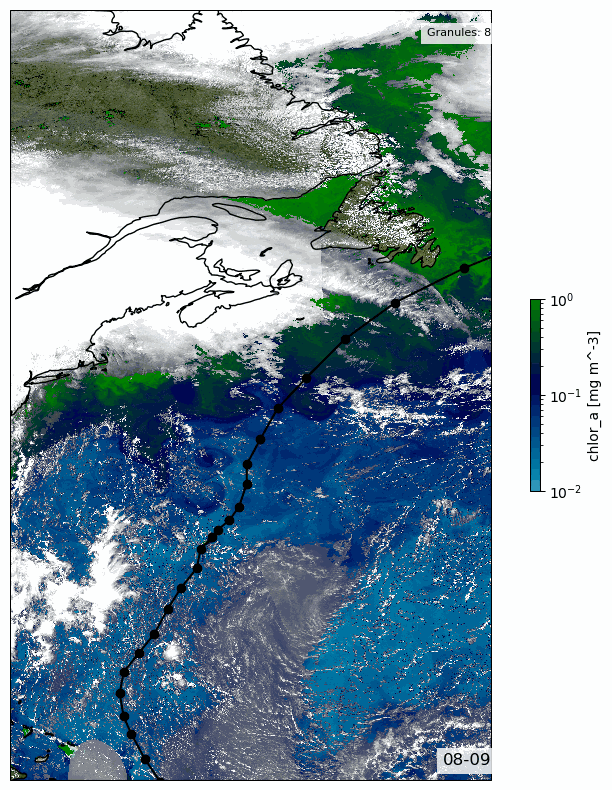

In [ ]:
# Produce BGC TC overlay gif with hurrican track
#Get hurricane track path for overlay
track = get_hurricane_path('al052024')  #Ernesto al052024

for i, (date, paths) in enumerate(paths_by_date.items()):
    print(f"Date: {date}")
    print(f"Paths: {paths}")
    # Perform operations on the first iteration
    data = coregister_granules_SREF(paths, crs, shape, transform, var_name)
    data_BGC = coregister_granules(paths_by_date_BGC[date], crs_BGC, shape_BGC, transform_BGC, "chlor_a")
    data_BGC = data_BGC.drop_vars("spatial_ref", errors="ignore")

    data_2 = data.assign_coords(wavelength_3d=wl)
    rhos_rgb = data_2.sel(wavelength_3d=[610, 555, 465], method="nearest")

    img_array = rhos_rgb.transpose("time", "latitude", "longitude", "wavelength_3d")
    zero_mask = (img_array == 0).all(dim="wavelength_3d")
    img_array = img_array.where(~zero_mask)
    img_array = img_array.mean("time")

    rgb = enhance(img_array)

    fig = plt.figure(figsize=(10, 10))
    axes = plt.subplot(projection=ccrs.PlateCarree())
    artist = axes.pcolormesh(
        rgb["longitude"],
        rgb["latitude"],
        rgb,
        shading="nearest",
        rasterized=True,
    )
    plot = data_BGC.mean("time").plot(
        x="longitude", y="latitude",
        cmap=plt.cm.colors.ListedColormap(cmaps.ocean_r(np.linspace(.25, 1, 256))),
        norm=LogNorm(vmin=0.01, vmax=1),
        ax=axes,
        alpha=1,  # Add transparency so the RGB background shows through, 1 is opaque
        add_colorbar=False,  # Add colorbar for diatoms
        transform=ccrs.PlateCarree()
    )
    axes.plot(track['Longitude'], track['Latitude'], color='black', marker='o', transform=ccrs.PlateCarree(), label='Observed Track')
    cbar = axes.figure.colorbar(plot, orientation='vertical', pad=0.05, shrink=0.25)
    cbar.set_label("chlor_a [mg m^-3]")
    axes.set_aspect("equal")
    axes.set_xlim(bbox[0],bbox[2])
    axes.set_ylim(bbox[1],bbox[3])
    axes.coastlines()
    # axes.gridlines(draw_labels={"left": "y", "bottom": "x"}) #Uncomment to add lat/lon gridlines
    date_str = [date.strftime('%m-%d') for date in data["time"].dt.date.values]
    plt.text(
        1, 0.025,  # Coordinates in axes fraction (relative to the plot)
        f'{date_str[0]}',
        transform=axes.transAxes,  # Use axes coordinates
        fontsize=12,
        ha="right",  # Align text to the right
        va="center",  # Align text to the bottom
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")  # Add a background box
    )
    plt.text(
        1, 1-0.03,  # Coordinates in axes fraction (relative to the plot)
        f'Granules: {data_2.shape[0]}',
        transform=axes.transAxes,  # Use axes coordinates
        fontsize=8,
        ha="right",  # Align text to the right
        va="center",  # Align text to the bottom
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")  # Add a background box
    )
    
    plt.savefig(local_data_path+'outputs'+'/HumbertoTC_BCG'+str(i).zfill(3)+'.png', bbox_inches='tight')
    
    plt.close()
    #break #IMPORTANT uncomment break if you want to get only one image for testing

# Define the folder containing the images and the output GIF path
image_folder = local_data_path+'outputs/'
output_gifBGC = local_data_path+'outputs/'+"Ernestorgbchla.gif"
print('got here')
# Get a sorted list of image file paths
image_files = sorted(glob.glob(os.path.join(image_folder, "*BCG*.png")))

# Read images and create the GIF
frames = []
for image in image_files:
    frames.append(imageio.imread(image))
imageio.mimsave(output_gifBGC, frames, fps=1, loop=0)  

# Display the GIF in the notebook
gifImage(filename=output_gifBGC)



## Now let's do some science

### User Inputs: Processing Parameters

This next section of the notebook coregisters granules across the pre, post, and post-post time spans rather than by date, which makes better use of dask's functionality (provided you have enough computation power)

In [9]:
# Load in all relevant pre-event and post-event granules
#   Steps:
#       - Use earthaccess.search_data to make lists of pre and post event files
#       - Open first entry of list manually, manipulate to L3M-like format and store relevant grid configuration info
#       - Using dask, open event granules, recast to L3M-like mapped format, trim to spatial extent, combine 2 datasets

# User definitions:
tspan = ("2024-08-09", "2024-08-30")    # define your pre-event and post-event timespans

min_lon = -82       # Set lat/lon extent for area of interest
min_lat = 25 
max_lon = -55
max_lat = 33

# OCI suite and variable of interest within a particular suite
suite_name="PACE_OCI_L2_BGC" # shortname of the suite, e.g. For PACE: PACE_OCI_L2_BGC_NRT, PACE_OCI_L2_AOP_NRT, etc. (plan to add more to this comment)
var_name = "chlor_a" # variable of interest

in_the_cloud = False # set to true if running in cloud (e.g. Cryocloud), false if running locally. For speed, granules will be downloaded to a local_data directory when set to false

# Load in all relevant pre-event and post-event granules
#   Steps:
#       - Use earthaccess.search_data to make lists of pre and post event files
#       - Open first entry of list manually, manipulate to L3M-like format and store relevant grid configuration info
#       - Using dask, open event granules, recast to L3M-like mapped format, trim to spatial extent, combine 2 datasets

# Set bounding box for earthdata search
bbox = (min_lon, min_lat, max_lon, max_lat)

# Perform the earthdata search:
results = earthaccess.search_data(
    short_name=suite_name,
    temporal=tspan,
    bounding_box=bbox,
)
print(" Number of event granules: "+str(len(results)))

# if not in the cloud, make a folder to downlad granules to. This folder is configured in the .gitignore to not be tracked
if in_the_cloud == False:
    os.makedirs('local_data/', exist_ok=True)

# in running this script in the cloud, earthaccess.open is fast, but when running locally it takes a long time (10+ min), and locally downloading the data is faster.
# so, get the data with different approaches, depening on whether you are in the cloud or not, defined above
if in_the_cloud == True:
    paths = earthaccess.open(results)
else:
    paths = earthaccess.download(results, local_path="local_data/Hurricane_Ernesto/")
    print('Files Downloaded')

# extract the geospatial characteristics from the first file in paths
crs, shape, transform = load_first(paths[0], var_name) # once set, dont need to rerun for other vars in same suite
data_BGC = coregister_granules(paths, crs, shape, transform, var_name)

 Number of event granules: 70


QUEUEING TASKS | : 100%|██████████| 70/70 [00:00<00:00, 5446.14it/s]
PROCESSING TASKS | : 100%|██████████| 70/70 [00:00<00:00, 154608.36it/s]
COLLECTING RESULTS | : 100%|██████████| 70/70 [00:00<00:00, 99864.38it/s]

Files Downloaded


loaded pre event files


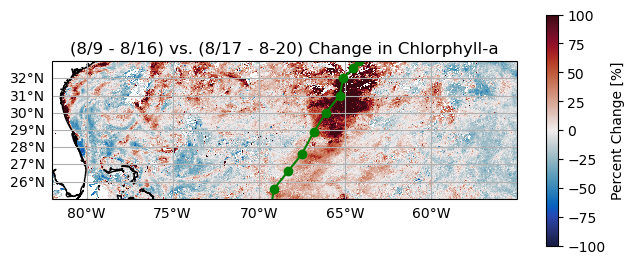

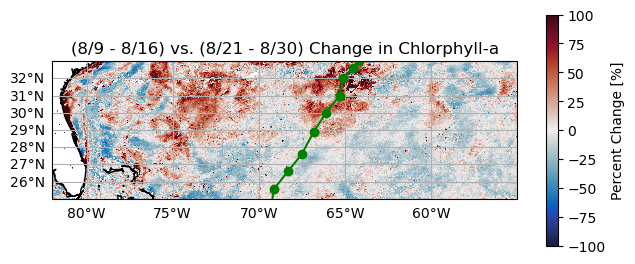

In [10]:
# compare the pre and post event data. first, mask both to only pixels where data is available before and after the hurricane
# then, mask each where it's values are greater or less than
pre_tspan = ("2024-08-09", "2024-08-16")    # define your pre-event and post-event timespans
post_tspan_short = ("2024-08-17", "2024-08-20")
post_tspan_long = ("2024-08-21", "2024-08-30")

#tspan = ("2025-09-14", "2025-10-10")

# Calculate mean over pre and post event periods
pre_mean = data_BGC.sel(time=slice(pre_tspan[0], pre_tspan[1])).mean("time")
post_mean_short = data_BGC.sel(time=slice(post_tspan_short[0], post_tspan_short[1])).mean("time")
post_mean_long = data_BGC.sel(time=slice(post_tspan_long[0], post_tspan_long[1])).mean("time") 

# Create a mask where both datasets have valid values
maskshort = ~np.isnan(post_mean_short) & ~np.isnan(pre_mean)
masklong = ~np.isnan(post_mean_long) & ~np.isnan(pre_mean)

# Apply masks to datasets
# Calculate percent change over pre and post event periods during "short" post-event window
pre_mean_mask_short = pre_mean.where(maskshort)
post_mean_mask_short = post_mean_short.where(maskshort)
post_greater_short = (post_mean_mask_short-pre_mean_mask_short)/pre_mean_mask_short * 100

# Calculate percent change over pre and post event periods during "long" post-event window
pre_mean_mask_long = pre_mean.where(masklong)
post_mean_mask_long = post_mean_long.where(masklong)
post_greater_long = (post_mean_mask_long-pre_mean_mask_long)/pre_mean_mask_long * 100

#Get hurricane track path for overlay
track = get_hurricane_path('al052024')  #Ernesto al052024


# Plot percent change during short post-event window
fig,ax = plt.subplots(1, 1, figsize=(7.5, 6), subplot_kw={'projection': ccrs.PlateCarree()})
ax.gridlines(draw_labels={"left": "y", "bottom": "x"})
plot = post_greater_short.plot(x="longitude", y="latitude" , cbar_kwargs={'label': 'Percent Change [%]', 'shrink':0.5}, cmap=cmocean.cm.balance, extend = "neither", ax=ax, robust=True, vmin=-100, vmax=100)
ax.plot(track['Longitude'], track['Latitude'], color='green', marker='o', transform=ccrs.PlateCarree(), label='Observed Track')
ax.set_xlim(bbox[0],bbox[2])
ax.set_ylim(bbox[1],bbox[3])
ax.coastlines()
ax.set_title('(8/9 - 8/16) vs. (8/17 - 8-20) Change in Chlorphyll-a')

# Save figure
plt.savefig(local_data_path+'outputs/'+'HumbertoChlaChange_shortpost.png', dpi=300, bbox_inches='tight')

# Plot percent change during long post-event window
fig,ax = plt.subplots(1, 1, figsize=(7.5, 6), subplot_kw={'projection': ccrs.PlateCarree()})
ax.gridlines(draw_labels={"left": "y", "bottom": "x"})
plot = post_greater_long.plot(x="longitude", y="latitude" , cbar_kwargs={'label': 'Percent Change [%]', 'shrink':0.5}, cmap=cmocean.cm.balance, extend = "neither", ax=ax, robust=True, vmin=-100, vmax=100)
ax.plot(track['Longitude'], track['Latitude'], color='green', marker='o', transform=ccrs.PlateCarree(), label='Observed Track')
ax.set_xlim(bbox[0],bbox[2])
ax.set_ylim(bbox[1],bbox[3])
ax.coastlines()
ax.set_title('(8/9 - 8/16) vs. (8/21 - 8/30) Change in Chlorphyll-a')

# Save figure
plt.savefig(local_data_path+'outputs/'+'ErnestoChlaChange_longpost.png', dpi=300, bbox_inches='tight')

### Let's first take a look at how chlorophyll-a changes before and after the event

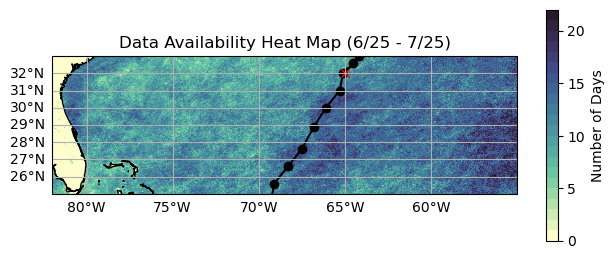

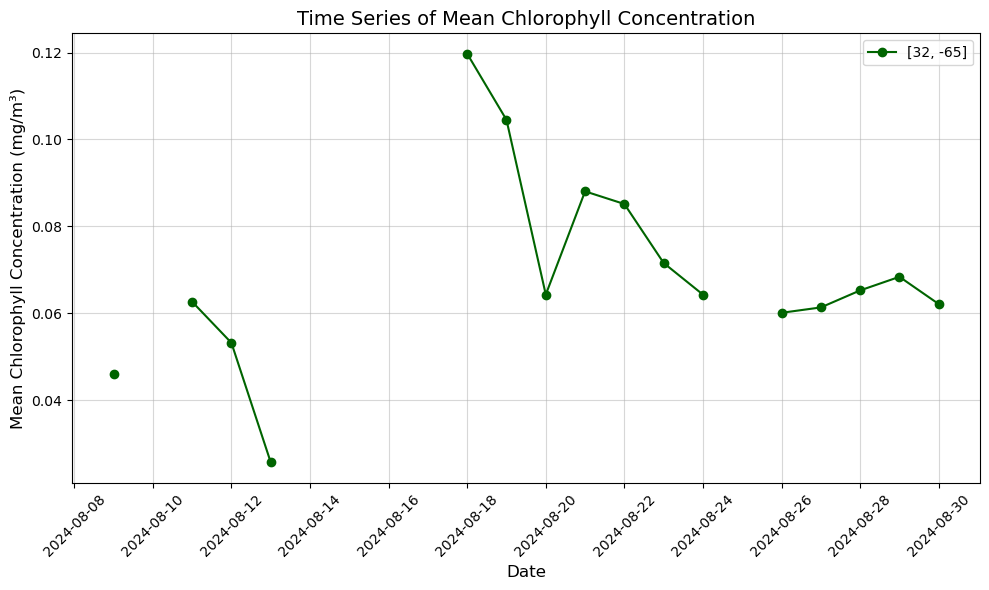

<Figure size 640x480 with 0 Axes>

In [12]:
## Chlorophyll-a time series at a point
# Define the target lat/lon coordinates
#tar_coords_1 = [32, -65.1] #26th target point for Humberto
tar_coords_1 = [32, -65] #26th target point for Humberto
#tar_coords_1 = [30, -67] #27th target point for Humberto
#tar_coords_1 = [27, -68] #28th target point for Humberto

# Data availability heat map
# Group the data by date and compute the mean for each group
data_BGC_by_date = data_BGC.groupby(data_BGC['time'].dt.date).mean(dim='time')
# Count the number of non-NaN values across the time dimension
data_count = data_BGC_by_date.count(dim='date')
# Get the total number of days in the 'date' dimension
total_days = len(data_BGC_by_date['date'])

# Create a discrete colormap with `total_days` colors
discrete_cmap = ListedColormap(cmocean.cm.deep(np.linspace(0, 1, total_days)))

# Define boundaries for the colormap
boundaries = np.arange(0, total_days + 1)  # One boundary for each day

# Plot data availability heat map
fig,ax = plt.subplots(1, 1, figsize=(7.5, 6), subplot_kw={'projection': ccrs.PlateCarree()})
data_count.plot(
    x='longitude',
    y='latitude',
    cmap=discrete_cmap,  # Use the discrete colormap
    cbar_kwargs={
        'label': 'Number of Days',
        'spacing': 'proportional',
        'pad': 0.05,
        'shrink': 0.5
    },
    vmin=0,
    vmax=total_days,  # Set color bar range
    ax=ax
)
ax.plot(track['Longitude'], track['Latitude'], color='black', marker='o', transform=ccrs.PlateCarree(), label='Observed Track')
ax.plot(tar_coords_1[1], tar_coords_1[0], color='red', marker='x', transform=ccrs.PlateCarree(), label='Target Point')
ax.set_xlim(bbox[0],bbox[2])
ax.set_ylim(bbox[1],bbox[3])
ax.gridlines(draw_labels={"left": "y", "bottom": "x"})
ax.coastlines()
ax.set_title('Data Availability Heat Map (6/25 - 7/25)')
# Save figure
plt.savefig(local_data_path+'outputs/'+ 'Data_Availability_Heat_Map.png', dpi=300, bbox_inches='tight')


# Extract chlorophyll-a time series at the target point
bgc_timeseries = data_BGC_by_date.sel(longitude=tar_coords_1[1], latitude=tar_coords_1[0], method='nearest')
# Determine the index of lat/lon to the target coordinate
tarcoords1_idx = [data_BGC_by_date.latitude.values.tolist().index(bgc_timeseries.latitude.values), \
                  data_BGC_by_date.longitude.values.tolist().index(bgc_timeseries.longitude.values)]
# Select adjacent data
tar1_data = data_BGC_by_date.isel(latitude=slice(tarcoords1_idx[0]-20, tarcoords1_idx[0]+30), \
                                  longitude=slice(tarcoords1_idx[1]-20, tarcoords1_idx[1]+30))
# Average over adjacent data 
tar1_data_mean = tar1_data.mean(dim=['latitude','longitude'])
# Extract the time values and chlorophyll concentrations for tar1_data_mean
time_values = tar1_data_mean['date'].values

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(time_values, tar1_data_mean.values, marker='o', linestyle='-', color=mcolors.CSS4_COLORS['darkgreen'], label=str(tar_coords_1))
# Format the x-axis to show dates
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Mean Chlorophyll Concentration (mg/m³)', fontsize=12)
ax.set_title('Time Series of Mean Chlorophyll Concentration', fontsize=14)
ax.grid(True, linestyle='-', alpha=0.5)
ax.legend()
# Set x-axis ticks to show every fourth day
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
# Rotate x-axis labels for better readability
plt.xticks(rotation=45)
plt.tight_layout()
# Show the plot
plt.show()
plt.savefig(local_data_path+'outputs/'+'Mean_Chlorophyll_Time_Series.png', dpi=300, bbox_inches='tight')



### How does the color of the ocean change (AVW)?

In [13]:
# Load in all relevant pre-event and post-event granules
#   Steps:
#       - Use earthaccess.search_data to make lists of pre and post event files
#       - Open first entry of list manually, manipulate to L3M-like format and store relevant grid configuration info
#       - Using dask, open event granules, recast to L3M-like mapped format, trim to spatial extent, combine 2 datasets

# User definitions:
tspan = ("2024-08-09", "2024-08-30")    # define your pre-event and post-event timespans

min_lon = -82       # Set lat/lon extent for area of interest
min_lat = 25 
max_lon = -55
max_lat = 33

# OCI suite and variable of interest within a particular suite
suite_name="PACE_OCI_L2_AOP" # shortname of the suite, e.g. For PACE: PACE_OCI_L2_BGC_NRT, PACE_OCI_L2_AOP_NRT, etc. (plan to add more to this comment)
var_name = "avw" # variable of interest

in_the_cloud = False # set to true if running in cloud (e.g. Cryocloud), false if running locally. For speed, granules will be downloaded to a local_data directory when set to false

# Load in all relevant pre-event and post-event granules
#   Steps:
#       - Use earthaccess.search_data to make lists of pre and post event files
#       - Open first entry of list manually, manipulate to L3M-like format and store relevant grid configuration info
#       - Using dask, open event granules, recast to L3M-like mapped format, trim to spatial extent, combine 2 datasets

# Set bounding box for earthdata search
bbox = (min_lon, min_lat, max_lon, max_lat)

# Perform the earthdata search:
results = earthaccess.search_data(
    short_name=suite_name,
    temporal=tspan,
    bounding_box=bbox,
)
print(" Number of event granules: "+str(len(results)))

# if not in the cloud, make a folder to downlad granules to. This folder is configured in the .gitignore to not be tracked
if in_the_cloud == False:
    os.makedirs('local_data/', exist_ok=True)

# in running this script in the cloud, earthaccess.open is fast, but when running locally it takes a long time (10+ min), and locally downloading the data is faster.
# so, get the data with different approaches, depening on whether you are in the cloud or not, defined above
if in_the_cloud == True:
    paths = earthaccess.open(results)
else:
    paths = earthaccess.download(results, local_path="local_data/Hurricane_Ernesto/")
    print('Files Downloaded')

# extract the geospatial characteristics from the first file in paths
crs, shape, transform = load_first(paths[0], var_name) # once set, dont need to rerun for other vars in same suite
data = coregister_granules(paths, crs, shape, transform, var_name)

 Number of event granules: 70


QUEUEING TASKS | : 100%|██████████| 70/70 [00:00<00:00, 4774.47it/s]
PROCESSING TASKS | : 100%|██████████| 70/70 [00:00<00:00, 195213.62it/s]
COLLECTING RESULTS | : 100%|██████████| 70/70 [00:00<00:00, 322284.61it/s]

Files Downloaded


loaded pre event files


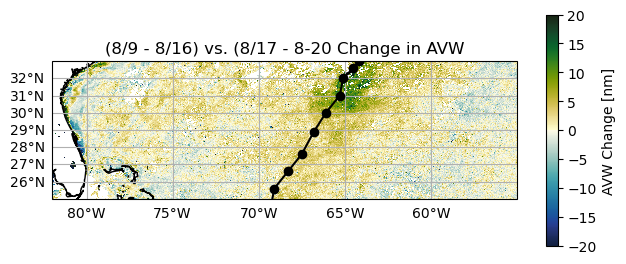

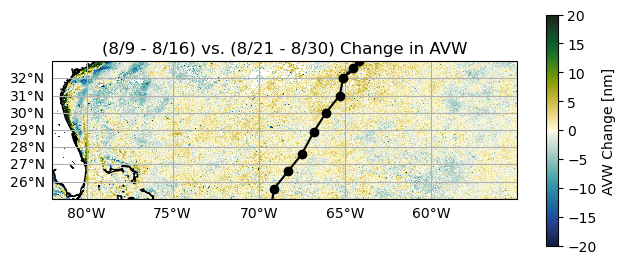

In [14]:
# compare the pre and post event data. first, mask both to only pixels where data is available before and after the hurricane
# then, mask each where it's values are greater or less than
pre_tspan = ("2024-08-09", "2024-08-16")    # define your pre-event and post-event timespans
post_tspan_short = ("2024-08-17", "2024-08-20")
post_tspan_long = ("2024-08-21", "2024-08-30")

#tspan = ("2025-09-14", "2025-10-10")

# Calculate mean over pre and post event periods
pre_mean = data.sel(time=slice(pre_tspan[0], pre_tspan[1])).mean("time")
post_mean_short = data.sel(time=slice(post_tspan_short[0], post_tspan_short[1])).mean("time")
post_mean_long = data.sel(time=slice(post_tspan_long[0], post_tspan_long[1])).mean("time") 

# Create a mask where both datasets have valid values
maskshort = ~np.isnan(post_mean_short) & ~np.isnan(pre_mean)
masklong = ~np.isnan(post_mean_long) & ~np.isnan(pre_mean)

# Apply masks to datasets
# Calculate percent change over pre and post event periods during "short" post-event window
pre_mean_mask_short = pre_mean.where(maskshort)
post_mean_mask_short = post_mean_short.where(maskshort)
post_greater_short = post_mean_mask_short-pre_mean_mask_short

# Calculate percent change over pre and post event periods during "long" post-event window
pre_mean_mask_long = pre_mean.where(masklong)
post_mean_mask_long = post_mean_long.where(masklong)
post_greater_long = post_mean_mask_long-pre_mean_mask_long

#Get hurricane track path for overlay
track = get_hurricane_path('al052024')  #Ernesto al052024

# Plot percent change during short post-event window
fig,ax = plt.subplots(1, 1, figsize=(7.5, 6), subplot_kw={'projection': ccrs.PlateCarree()})
ax.gridlines(draw_labels={"left": "y", "bottom": "x"})
plot = post_greater_short.plot(x="longitude", y="latitude" , cbar_kwargs={'label': 'AVW Change [nm]', 'shrink':0.5}, cmap=cmocean.cm.delta, extend = "neither", ax=ax, robust=True, vmin=-20, vmax=20)
ax.plot(track['Longitude'], track['Latitude'], color='black', marker='o', transform=ccrs.PlateCarree(), label='Observed Track')
ax.set_xlim(bbox[0],bbox[2])
ax.set_ylim(bbox[1],bbox[3])
ax.coastlines()
ax.set_title('(8/9 - 8/16) vs. (8/17 - 8-20 Change in AVW')

# Save figure
plt.savefig(local_data_path+'outputs/'+'AVWChange_shortpost.png', dpi=300, bbox_inches='tight')

# Plot percent change during long post-event window
fig,ax = plt.subplots(1, 1, figsize=(7.5, 6), subplot_kw={'projection': ccrs.PlateCarree()})
ax.gridlines(draw_labels={"left": "y", "bottom": "x"})
plot = post_greater_long.plot(x="longitude", y="latitude" , cbar_kwargs={'label': 'AVW Change [nm]', 'shrink':0.5}, cmap=cmocean.cm.delta, extend = "neither", ax=ax, robust=True, vmin=-20, vmax=20)
ax.plot(track['Longitude'], track['Latitude'], color='black', marker='o', transform=ccrs.PlateCarree(), label='Observed Track')
ax.set_xlim(bbox[0],bbox[2])
ax.set_ylim(bbox[1],bbox[3])
ax.coastlines()
ax.set_title('(8/9 - 8/16) vs. (8/21 - 8/30) Change in AVW')

# Save figure
plt.savefig(local_data_path+'outputs/'+'AVWChange_longpost.png', dpi=300, bbox_inches='tight')

In [16]:
# MOANA Data Analysis

# Date range for data search
tspan = ("2024-08-09", "2024-08-20")    # define your pre-event and post-event timespans

# Add HH:MM:SS (set to noon UTC) to temporal span for earthaccess query
tspan_with_time = (f"{tspan[0]} 12:00:00", f"{tspan[1]} 12:00:00")

min_lon = -82       # Set lat/lon extent for area of interest
min_lat = 25 
max_lon = -55
max_lat = 33

in_the_cloud = False # set to true if running in cloud (e.g. Cryocloud), false if running locally. For speed, granules will be downloaded to a local_data directory when set to false

# Perform the earthdata search:
bbox = (min_lon, min_lat, max_lon, max_lat)

MOANNA_results = earthaccess.search_data(
    short_name="PACE_OCI_L4M_MOANA",
    temporal=tspan,
    bounding_box=bbox,
    granule_name="*.DAY.*4km*",
    version="3.1"
)

BGC_results = earthaccess.search_data(
    short_name="PACE_OCI_L3M_CHL",
    temporal=tspan,
    bounding_box=bbox,
    granule_name="*.DAY.*4km*",
    version="3.1"
)

# Search and download SST data
sst_results = earthaccess.search_data(
    short_name="MUR25-JPL-L4-GLOB-v04.2",
    temporal=tspan_with_time,
)

# in running this script in the cloud, earthaccess.open is fast, but when running locally it takes a long time (10+ min), and locally downloading the data is faster.
# so, get the data with different approaches, depening on whether you are in the cloud or not, defined above
if in_the_cloud == True:
    paths_MOANA = earthaccess.open(MOANNA_results)
else:
    paths_MOANA = earthaccess.download(MOANNA_results, local_path="local_data/Hurricane_Ernesto/")

# in running this script in the cloud, earthaccess.open is fast, but when running locally it takes a long time (10+ min), and locally downloading the data is faster.
# so, get the data with different approaches, depening on whether you are in the cloud or not, defined above
if in_the_cloud == True:
    paths_BGC = earthaccess.open(BGC_results)
else:
    paths_BGC = earthaccess.download(BGC_results, local_path="local_data/Hurricane_Ernesto/")

if in_the_cloud == True:
    paths_sst = earthaccess.open(sst_results)
else:
    paths_sst = earthaccess.download(sst_results, local_path="local_data/Hurricane_Ernesto/")





QUEUEING TASKS | : 100%|██████████| 12/12 [00:00<00:00, 2450.54it/s]
PROCESSING TASKS | : 100%|██████████| 12/12 [00:00<00:00, 69808.11it/s]
COLLECTING RESULTS | : 100%|██████████| 12/12 [00:00<00:00, 120410.64it/s]
QUEUEING TASKS | : 100%|██████████| 12/12 [00:00<00:00, 1925.02it/s]
PROCESSING TASKS | : 100%|██████████| 12/12 [00:00<00:00, 65112.09it/s]
COLLECTING RESULTS | : 100%|██████████| 12/12 [00:00<00:00, 85307.88it/s]
QUEUEING TASKS | : 100%|██████████| 12/12 [00:00<00:00, 2443.76it/s]
PROCESSING TASKS | : 100%|██████████| 12/12 [00:00<00:00, 70591.37it/s]
COLLECTING RESULTS | : 100%|██████████| 12/12 [00:00<00:00, 111353.20it/s]


In [17]:
dataset_MOANA = xr.open_mfdataset(paths_MOANA, preprocess=time_from_attr_L4MOANNA, combine='nested', concat_dim='time')
dataset_BGC = xr.open_mfdataset(paths_BGC, preprocess=time_from_attr_L4MOANNA, combine='nested', concat_dim='time')
dataset_sst = xr.open_mfdataset(paths_sst, preprocess=time_from_attr_sst, combine='nested', concat_dim='time')

print(dataset_MOANA.time.values)
print(dataset_BGC.time.values)

# Set SST time variables to midnight for consistency
dataset_sst = dataset_sst.assign_coords(time=dataset_sst['time'].dt.floor('D'))
print(dataset_sst.time.values)

# Define the target lat/lon coordinates
tar_coords_1 = [32, -65.1] #26th target point for Humberto

# Get min/max values of L4 dataset withing bounding box coordinates for later plotting
date_str = [str(date) for date in dataset_MOANA["time"].dt.date.values]

# Calculate 2-day coarsened mean of L3 & L4M data products
MOANA_mean_2 = dataset_MOANA.coarsen(time=2, boundary='trim').mean()

BGC_mean_2 = dataset_BGC.coarsen(time=2, boundary='trim').mean()

# Get the total number of days in the 'time' dimension
total_days = len(dataset_MOANA['time'])

['2024-08-09T00:00:00' '2024-08-10T00:00:00' '2024-08-11T00:00:00'
 '2024-08-12T00:00:00' '2024-08-13T00:00:00' '2024-08-14T00:00:00'
 '2024-08-15T00:00:00' '2024-08-16T00:00:00' '2024-08-17T00:00:00'
 '2024-08-18T00:00:00' '2024-08-19T00:00:00' '2024-08-20T00:00:00']
['2024-08-09T00:00:00' '2024-08-10T00:00:00' '2024-08-11T00:00:00'
 '2024-08-12T00:00:00' '2024-08-13T00:00:00' '2024-08-14T00:00:00'
 '2024-08-15T00:00:00' '2024-08-16T00:00:00' '2024-08-17T00:00:00'
 '2024-08-18T00:00:00' '2024-08-19T00:00:00' '2024-08-20T00:00:00']
['2024-08-09T00:00:00.000000000' '2024-08-10T00:00:00.000000000'
 '2024-08-11T00:00:00.000000000' '2024-08-12T00:00:00.000000000'
 '2024-08-13T00:00:00.000000000' '2024-08-14T00:00:00.000000000'
 '2024-08-15T00:00:00.000000000' '2024-08-16T00:00:00.000000000'
 '2024-08-17T00:00:00.000000000' '2024-08-18T00:00:00.000000000'
 '2024-08-19T00:00:00.000000000' '2024-08-20T00:00:00.000000000']


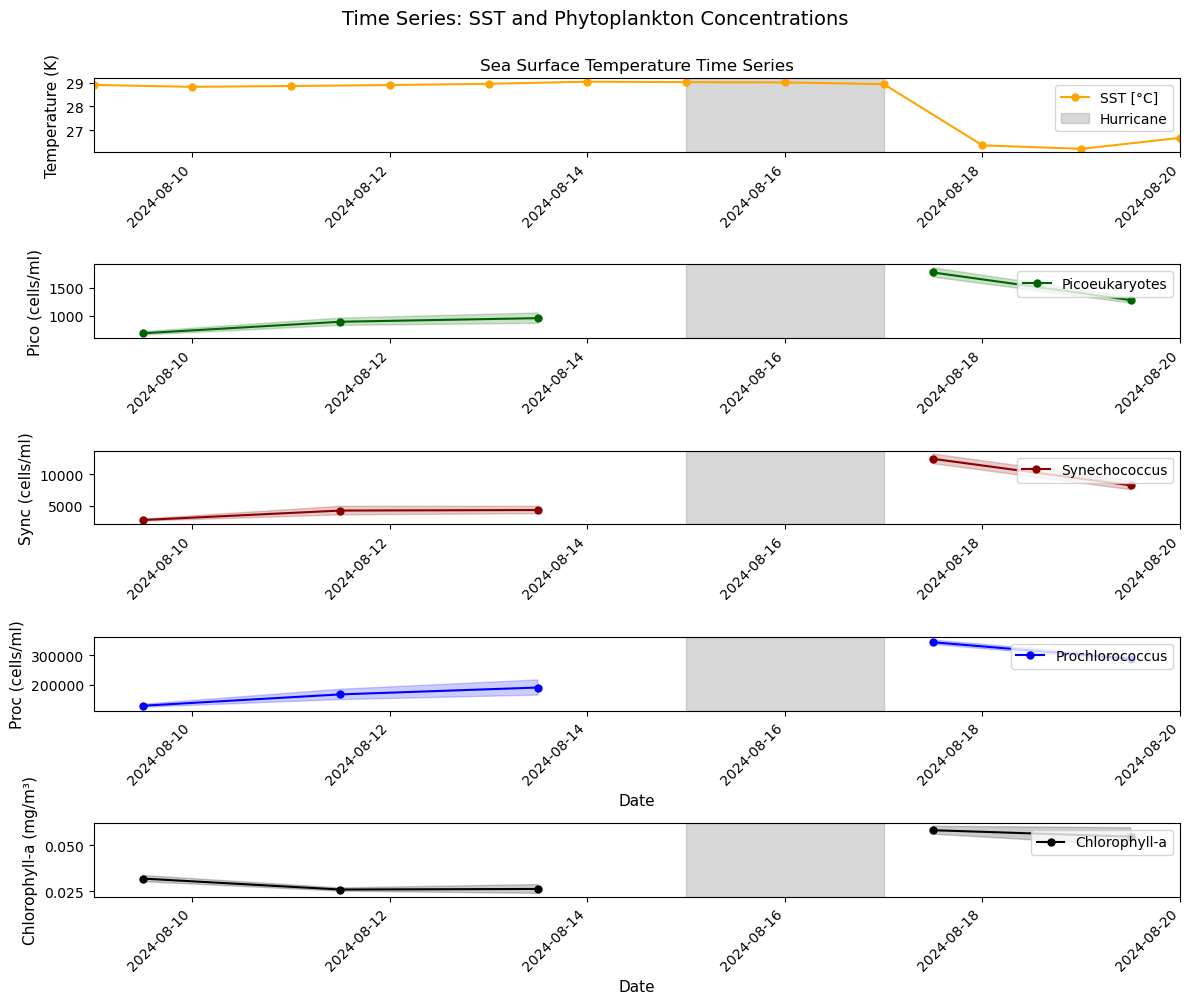

In [58]:
tar_coords_1 = [30.6, -66.2] #26th target point for Humberto
#[30.6, -66] decent
#############################MOANA Data Extraction############################

# Find the nearest point to the target lat/lon coordinates
datanear =  MOANA_mean_2.sel(lat=tar_coords_1[0], lon=tar_coords_1[1], method='nearest')

# Determine the index of lat/lon to the target coordinate
MOANA_tar_idx = [MOANA_mean_2.lat.values.tolist().index(datanear.lat.values), \
                  MOANA_mean_2.lon.values.tolist().index(datanear.lon.values)]
# Select adjacent data
MOANA_data = MOANA_mean_2.isel(lat=slice(MOANA_tar_idx[0]-2, MOANA_tar_idx[0]+3), \
                                  lon=slice(MOANA_tar_idx[1]-2, MOANA_tar_idx[1]+3))
MOANA_std = dataset_MOANA.isel(lat=slice(MOANA_tar_idx[0]-2, MOANA_tar_idx[0]+3), \
                                  lon=slice(MOANA_tar_idx[1]-2, MOANA_tar_idx[1]+3))

# Calculate the mean of the selected adjacent data
MOANA_data = MOANA_data.mean(dim=['lat','lon']) #
MOANA_std = MOANA_std.std(dim=['lat','lon'])
MOANA_std = MOANA_std.coarsen(time=2, boundary='trim').mean()

###########################BGC Data Extraction########################
# Find the nearest point to the target lat/lon coordinates
datanear =  BGC_mean_2.sel(lat=tar_coords_1[0], lon=tar_coords_1[1], method='nearest')

# Determine the index of lat/lon to the target coordinate
BGC_tar_idx = [BGC_mean_2.lat.values.tolist().index(datanear.lat.values), \
                  BGC_mean_2.lon.values.tolist().index(datanear.lon.values)]
# Select adjacent data
BGC_data = BGC_mean_2.isel(lat=slice(BGC_tar_idx[0]-2, BGC_tar_idx[0]+3), \
                                  lon=slice(BGC_tar_idx[1]-2, BGC_tar_idx[1]+3))
BGC_std = dataset_BGC.isel(lat=slice(BGC_tar_idx[0]-2, BGC_tar_idx[0]+3), \
                                  lon=slice(BGC_tar_idx[1]-2, BGC_tar_idx[1]+3))

# Calculate the mean of the selected adjacent data
BGC_data = BGC_data.mean(dim=['lat','lon']) #
BGC_std = BGC_std.std(dim=['lat','lon'])
BGC_std = BGC_std.coarsen(time=2, boundary='trim').mean()

#############################SST Data Extraction############################
# Find the nearest point to the target lat/lon coordinates
sst_datanear = dataset_sst.sel(lat=tar_coords_1[0], lon=tar_coords_1[1], method='nearest')

# Determine the index of lat/lon to the target coordinate
sst_tarcoords_idx = [dataset_sst.lat.values.tolist().index(sst_datanear.lat.values), \
                     dataset_sst.lon.values.tolist().index(sst_datanear.lon.values)]

# Select adjacent data (1x1 pixel grid)
tar1_data_sst = dataset_sst.isel(lat=slice(sst_tarcoords_idx[0], sst_tarcoords_idx[0]+1), \
                                 lon=slice(sst_tarcoords_idx[1], sst_tarcoords_idx[1]+1))

# Calculate the mean of the selected adjacent data
SST_data = tar1_data_sst.mean(dim=['lat','lon']) - 273.15  # Convert from Kelvin to Celsius

# Create 4x1 subplot layout
fig, ax = plt.subplots(5, 1, figsize=(12, 10))

# Extract time values
sst_time_values = SST_data['time'].values
moana_time_values = MOANA_data['time'].values
bgc_time_values = BGC_data['time'].values


# Plot 1: SST
ax[0].plot(sst_time_values,
           SST_data['analysed_sst'].values,
           'o-',
           color=mcolors.CSS4_COLORS['orange'],
           label="SST [°C]",
           markersize=5)
ax[0].axvspan(np.datetime64('2024-08-15'), np.datetime64('2024-08-17'), 
              color='gray', alpha=0.3, label='Hurricane')
ax[0].set_ylabel('Temperature (K)', fontsize=11)
ax[0].set_title('Sea Surface Temperature Time Series', fontsize=12)
ax[0].legend(loc='upper right', frameon=True, framealpha=0.8)

# Plot 2: Picoeukaryotes
ax[1].plot(moana_time_values,
           MOANA_data['picoeuk_moana'].values,
           'o-',
           color=mcolors.CSS4_COLORS['darkgreen'],
           label="Picoeukaryotes",
           markersize=5)
ax[1].fill_between(moana_time_values,
                   MOANA_data['picoeuk_moana'].values - MOANA_std['picoeuk_moana'].values,
                   MOANA_data['picoeuk_moana'].values + MOANA_std['picoeuk_moana'].values,
                   color=mcolors.CSS4_COLORS['darkgreen'],
                   alpha=0.2)
ax[1].axvspan(np.datetime64('2024-08-15'), np.datetime64('2024-08-17'), 
              color='gray', alpha=0.3)
ax[1].set_ylabel('Pico (cells/ml)', fontsize=11)
ax[1].legend(loc='upper right', frameon=True, framealpha=0.8)

# Plot 3: Synechococcus
ax[2].plot(moana_time_values,
           MOANA_data['syncoccus_moana'].values,
           'o-',
           color=mcolors.CSS4_COLORS['darkred'],
           label="Synechococcus",
           markersize=5)
ax[2].fill_between(moana_time_values,
                   MOANA_data['syncoccus_moana'].values - MOANA_std['syncoccus_moana'].values,
                   MOANA_data['syncoccus_moana'].values + MOANA_std['syncoccus_moana'].values,
                   color=mcolors.CSS4_COLORS['darkred'],
                   alpha=0.2)
ax[2].axvspan(np.datetime64('2024-08-15'), np.datetime64('2024-08-17'), 
              color='gray', alpha=0.3)
ax[2].set_ylabel('Sync (cells/ml)', fontsize=11)
ax[2].legend(loc='upper right', frameon=True, framealpha=0.8)

# Plot 4: Prochlorococcus
ax[3].plot(moana_time_values,
           MOANA_data['prococcus_moana'].values,
           'o-',
           color=mcolors.CSS4_COLORS['blue'],
           label="Prochlorococcus",
           markersize=5)
ax[3].fill_between(moana_time_values,
                   MOANA_data['prococcus_moana'].values - MOANA_std['prococcus_moana'].values,
                   MOANA_data['prococcus_moana'].values + MOANA_std['prococcus_moana'].values,
                   color=mcolors.CSS4_COLORS['blue'],
                   alpha=0.2)
ax[3].axvspan(np.datetime64('2024-08-15'), np.datetime64('2024-08-17'), 
              color='gray', alpha=0.3)
ax[3].set_ylabel('Proc (cells/ml)', fontsize=11)
ax[3].set_xlabel('Date', fontsize=11)
ax[3].legend(loc='upper right', frameon=True, framealpha=0.8)

# Plot 4: Chlorophyll-a
ax[4].plot(bgc_time_values,
           BGC_data['chlor_a'].values,
           'o-',
           color=mcolors.CSS4_COLORS['black'],
           label="Chlorophyll-a",
           markersize=5)
ax[4].fill_between(bgc_time_values,
                   BGC_data['chlor_a'].values - BGC_std['chlor_a'].values,
                   BGC_data['chlor_a'].values + BGC_std['chlor_a'].values,
                   color=mcolors.CSS4_COLORS['black'],
                   alpha=0.2)
ax[4].axvspan(np.datetime64('2024-08-15'), np.datetime64('2024-08-17'), 
              color='gray', alpha=0.3)
ax[4].set_ylabel('Chlorophyll-a (mg/m³)', fontsize=11)
ax[4].set_xlabel('Date', fontsize=11)
ax[4].legend(loc='upper right', frameon=True, framealpha=0.8)


# Format x-axis for all subplots
for axis in ax:
    axis.xaxis.set_major_locator(mdates.DayLocator(interval=2))
    axis.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    axis.set_xlim(np.datetime64(tspan[0]), np.datetime64(tspan[1]))
    plt.setp(axis.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.suptitle('Time Series: SST and Phytoplankton Concentrations', fontsize=14, y=1.00)
plt.tight_layout()
plt.savefig(local_data_path+'outputs/'+'Ernesto_MOANA_SST_CHL_TimeSeries_stack.png', dpi=300, bbox_inches='tight')
plt.show()

/accounts/gtrolley/miniforge3/envs/env/lib/python3.14/site-packages/dask/array/numpy_compat.py:58: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/accounts/gtrolley/miniforge3/envs/env/lib/python3.14/site-packages/dask/array/numpy_compat.py:58: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/accounts/gtrolley/miniforge3/envs/env/lib/python3.14/site-packages/dask/array/numpy_compat.py:58: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/accounts/gtrolley/miniforge3/envs/env/lib/python3.14/site-packages/dask/array/numpy_compat.py:58: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/accounts/gtrolley/miniforge3/envs/env/lib/python3.14/site-packages/dask/array/numpy_compat.py:58: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/accounts/gtrolley/miniforge3/envs/env/lib/python3.14/site-packages/dask/array/numpy_compat.py:58: R

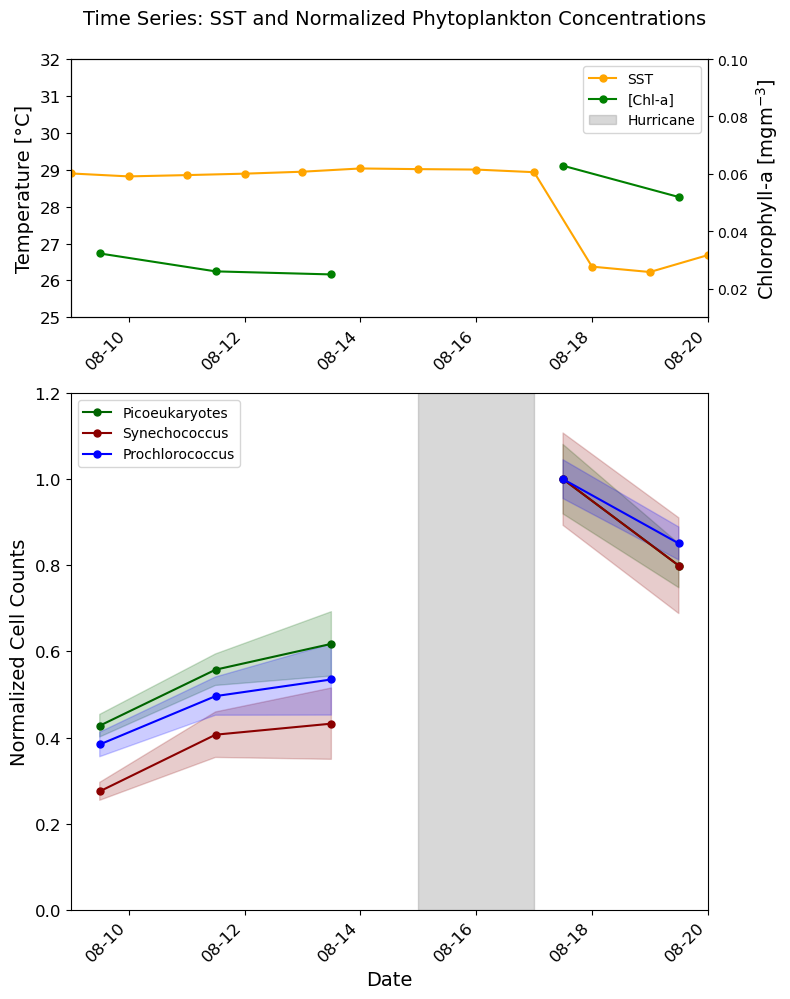

In [60]:
# Normalize phytoplankton functional type plots

# Find the nearest point to the target lat/lon coordinates
datanear =  MOANA_mean_2.sel(lat=tar_coords_1[0], lon=tar_coords_1[1], method='nearest')

# Determine the index of lat/lon to the target coordinate
MOANA_tar_idx = [MOANA_mean_2.lat.values.tolist().index(datanear.lat.values), \
                  MOANA_mean_2.lon.values.tolist().index(datanear.lon.values)]
# Select adjacent data
MOANA_data = MOANA_mean_2.isel(lat=slice(MOANA_tar_idx[0]-4, MOANA_tar_idx[0]+5), \
                                  lon=slice(MOANA_tar_idx[1]-4, MOANA_tar_idx[1]+5))
MOANA_std = dataset_MOANA.isel(lat=slice(MOANA_tar_idx[0]-4, MOANA_tar_idx[0]+5), \
                                  lon=slice(MOANA_tar_idx[1]-4, MOANA_tar_idx[1]+5))

# Calculate the mean of the selected adjacent data
MOANA_data = MOANA_data.mean(dim=['lat','lon']) #
MOANA_std = MOANA_std.std(dim=['lat','lon'])
MOANA_std = MOANA_std.coarsen(time=2, boundary='trim').mean()

###########################BGC Data Extraction########################
# Find the nearest point to the target lat/lon coordinates
datanear =  BGC_mean_2.sel(lat=tar_coords_1[0], lon=tar_coords_1[1], method='nearest')

# Determine the index of lat/lon to the target coordinate
BGC_tar_idx = [BGC_mean_2.lat.values.tolist().index(datanear.lat.values), \
                  BGC_mean_2.lon.values.tolist().index(datanear.lon.values)]
# Select adjacent data
BGC_data = BGC_mean_2.isel(lat=slice(BGC_tar_idx[0]-4, BGC_tar_idx[0]+5), \
                                  lon=slice(BGC_tar_idx[1]-4, BGC_tar_idx[1]+5))
BGC_std = dataset_BGC.isel(lat=slice(BGC_tar_idx[0]-4, BGC_tar_idx[0]+5), \
                                  lon=slice(BGC_tar_idx[1]-4, BGC_tar_idx[1]+5))

# Calculate the mean of the selected adjacent data
BGC_data = BGC_data.mean(dim=['lat','lon']) #
BGC_std = BGC_std.std(dim=['lat','lon'])
BGC_std = BGC_std.coarsen(time=2, boundary='trim').mean()

#############################SST Data Extraction############################
# Find the nearest point to the target lat/lon coordinates
sst_datanear = dataset_sst.sel(lat=tar_coords_1[0], lon=tar_coords_1[1], method='nearest')

# Determine the index of lat/lon to the target coordinate
sst_tarcoords_idx = [dataset_sst.lat.values.tolist().index(sst_datanear.lat.values), \
                     dataset_sst.lon.values.tolist().index(sst_datanear.lon.values)]

# Select adjacent data (1x1 pixel grid)
tar1_data_sst = dataset_sst.isel(lat=slice(sst_tarcoords_idx[0], sst_tarcoords_idx[0]+1), \
                                 lon=slice(sst_tarcoords_idx[1], sst_tarcoords_idx[1]+1))

# Calculate the mean of the selected adjacent data
SST_data = tar1_data_sst.mean(dim=['lat','lon']) - 273.15  # Convert from Kelvin to Celsius

# Normalize phytoplankton data to their maximum values
pico_norm = MOANA_data['picoeuk_moana'] / MOANA_data['picoeuk_moana'].max()
sync_norm = MOANA_data['syncoccus_moana'] / MOANA_data['syncoccus_moana'].max()
proc_norm = MOANA_data['prococcus_moana'] / MOANA_data['prococcus_moana'].max()

# Normalize standard deviations proportionally
pico_std_norm = MOANA_std['picoeuk_moana'] / MOANA_data['picoeuk_moana'].max()
sync_std_norm = MOANA_std['syncoccus_moana'] / MOANA_data['syncoccus_moana'].max()
proc_std_norm = MOANA_std['prococcus_moana'] / MOANA_data['prococcus_moana'].max()

# Create 2x1 subplot layout with different heights
fig, (ax_top, ax_bottom) = plt.subplots(2, 1, figsize=(8, 10), 
                                         gridspec_kw={'height_ratios': [1, 2]})

# Extract time values
sst_time_values = SST_data['time'].values
moana_time_values = MOANA_data['time'].values
bgc_time_values = BGC_data['time'].values

# Plot 1: SST (top panel)
ax_top.plot(sst_time_values,
            SST_data['analysed_sst'].values,
            'o-',
            color=mcolors.CSS4_COLORS['orange'],
            label="SST",
            markersize=5)
ax_top.axvspan(np.datetime64('2025-08-15'), np.datetime64('2025-08-16'), 
               color='gray', alpha=0.3, label='Hurricane')
ax_top.set_ylabel('Temperature [°C]', fontsize=14)
ax_top.set_ylim(25, 32)

# Create right y-axis for chlorophyll-a
ax_chl = ax_top.twinx()
ax_chl.plot(bgc_time_values, BGC_data['chlor_a'].values, 'o-',
            color=mcolors.CSS4_COLORS['green'], label="[Chl-a]", markersize=5)
# ax_chl.fill_between(bgc_time_values,
#                     (chl_norm - chl_std_norm).values,
#                     (chl_norm + chl_std_norm).values,
#                     color=mcolors.CSS4_COLORS['black'], alpha=0.2)
ax_chl.set_ylabel('Chlorophyll-a [mgm$^{-3}$]', fontsize=14, color=mcolors.CSS4_COLORS['black'])
ax_chl.tick_params(axis='y', labelcolor=mcolors.CSS4_COLORS['black'])
ax_chl.set_ylim(0.01, 0.1)

# Combine legends from both axes
handles_sst, labels_sst = ax_top.get_legend_handles_labels()
handles_chl, labels_chl = ax_chl.get_legend_handles_labels()

ax_top.legend(handles_sst[0:1] + handles_chl + handles_sst[1:2],
              labels_sst[0:1] + labels_chl + labels_sst[1:2],
              loc='upper right', frameon=True, framealpha=0.8)

# Bottom panel: All normalized phytoplankton on left, chlorophyll on right
# Plot all three phytoplankton on left axis
ax_bottom.plot(moana_time_values, pico_norm.values, 'o-',
               color=mcolors.CSS4_COLORS['darkgreen'], label="Picoeukaryotes", markersize=5)
ax_bottom.fill_between(moana_time_values,
                       (pico_norm - pico_std_norm).values,
                       (pico_norm + pico_std_norm).values,
                       color=mcolors.CSS4_COLORS['darkgreen'], alpha=0.2)

ax_bottom.plot(moana_time_values, sync_norm.values, 'o-',
               color=mcolors.CSS4_COLORS['darkred'], label="Synechococcus", markersize=5)
ax_bottom.fill_between(moana_time_values,
                       (sync_norm - sync_std_norm).values,
                       (sync_norm + sync_std_norm).values,
                       color=mcolors.CSS4_COLORS['darkred'], alpha=0.2)

ax_bottom.plot(moana_time_values, proc_norm.values, 'o-',
               color=mcolors.CSS4_COLORS['blue'], label="Prochlorococcus", markersize=5)
ax_bottom.fill_between(moana_time_values,
                       (proc_norm - proc_std_norm).values,
                       (proc_norm + proc_std_norm).values,
                       color=mcolors.CSS4_COLORS['blue'], alpha=0.2)

ax_bottom.set_ylabel('Normalized Cell Counts', fontsize=14)
ax_bottom.set_ylim(0, 1.2)


# Add event shading
ax_bottom.axvspan(np.datetime64('2024-08-15'), np.datetime64('2024-08-17'), 
                  color='gray', alpha=0.3)

# Labels and formatting
ax_bottom.set_xlabel('Date', fontsize=14)

# Combine legends from both axes
handles_phyto, labels_phyto = ax_bottom.get_legend_handles_labels()
handles_chl, labels_chl = ax_chl.get_legend_handles_labels()

ax_bottom.legend(handles_phyto,
                 labels_phyto,
                 loc='upper left', frameon=True, framealpha=0.8)

# Format x-axis for both subplots
for axis in [ax_top, ax_bottom]:
    axis.xaxis.set_major_locator(mdates.DayLocator(interval=2))
    axis.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    axis.xaxis.set_tick_params(labelsize=12)
    axis.yaxis.set_tick_params(labelsize=12)
    axis.set_xlim(np.datetime64(tspan[0]), np.datetime64(tspan[1]))
    plt.setp(axis.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.suptitle('Time Series: SST and Normalized Phytoplankton Concentrations', fontsize=14, y=0.995)
plt.tight_layout()

# Save figure
plt.savefig(local_data_path+'outputs'+'/Humberto_MOANA_SST_CHL_TimeSeries.png', dpi=300, bbox_inches='tight')
plt.show()